# RM/PM Demand EDA

Demand concentration, intermittency, outliers, ABC, and FMS classes.

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name != "v7_rm_pm_forecast_planning":
    ROOT = Path("Ai miroservices/modeling/v7_rm_pm_forecast_planning").resolve()
OUT = ROOT / "outputs"
pd.set_option("display.max_columns", 80)

In [2]:
classes = pd.read_csv(OUT / "demand_classification.csv")
classes.head(20)

,material_id,material_code,description,material_type,total_demand,avg_monthly_demand,std_monthly_demand,nonzero_months,months,max_monthly_demand,nonzero_rate,cv,demand_share,cumulative_share,abc_class,fms_class,intermittency_flag,planning_priority
0,5571d3cd-666f-4673-a41e-efeb313da005,100036,CAUSTIC SODA,raw_material,3406902.0,94636.166667,27697.536838,36,36,160600.0,1.0,0.292674,0.174162,0.174162,A,F,False,high_access_candidate
1,44dd0de1-d770-4f74-bccb-e6fc16f574ca,100098,SORBITOL,raw_material,2269171.0,63032.527778,18713.555906,36,36,102062.0,1.0,0.296887,0.116001,0.290162,A,F,False,high_access_candidate
2,ed5d69d5-7370-4a93-b888-2aa711897187,101054,CALCIUM CARBONATE ( GROUND ),raw_material,2198176.0,61060.444444,19956.763285,36,36,119439.0,1.0,0.326836,0.112371,0.402534,A,F,False,high_access_candidate
3,861bf563-9747-4508-96c0-5a0c976acbcd,101293,FLUFF UNTREATED - GOLDEN ISLES G4881,raw_material,2024498.0,56236.055556,18879.292700,36,36,109586.0,1.0,0.335715,0.103493,0.506027,A,F,False,high_access_candidate
4,3670333e-585b-4f10-9d15-912dcb65d820,100108,TALCUM POWDER,raw_material,1077195.0,29922.083333,14269.232922,36,36,61449.0,1.0,0.476880,0.055067,0.561093,A,F,False,high_access_candidate
5,584db23d-9317-457f-9e7d-d7592e043210,101580,SODIUM SILICATE,raw_material,840201.0,23338.916667,9568.979317,36,36,46891.0,1.0,0.410001,0.042951,0.604045,A,F,False,high_access_candidate
6,2b39aadc-6592-406c-914f-482f4cbb7ab5,100323,BC COLOGNE BULK - IMPORTED,raw_material,758946.0,21081.833333,4830.304507,36,36,37395.0,1.0,0.229122,0.038798,0.642842,A,F,False,high_access_candidate
7,9a11c556-2240-4f35-ae53-f0c8c8a88fb4,100460,GALAXY LES 70,raw_material,654388.0,18177.444444,6889.005665,36,36,37911.0,1.0,0.378986,0.033452,0.676295,A,F,False,high_access_candidate
8,e77e97bd-5de0-41f8-afc3-037acf6b900b,100050,GLYCERINE,raw_material,372491.0,10346.972222,2537.851999,36,36,13994.0,1.0,0.245275,0.019042,0.695336,A,F,False,high_access_candidate
9,decce9e4-20de-45c6-af1c-9d641542a43f,100714,COCOMIDOPROPYL BETAINE,raw_material,372426.0,10345.166667,3778.796509,36,36,17301.0,1.0,0.365272,0.019039,0.714375,A,F,False,high_access_candidate


In [3]:
classes.groupby(["abc_class", "fms_class"]).size().unstack(fill_value=0)

fms_class,F,M,S
abc_class,,,
A,17,0,0
B,40,0,0
C,178,15,38


In [4]:
classes[["material_code", "description", "material_type", "total_demand", "abc_class", "fms_class", "nonzero_rate", "cv", "planning_priority"]].head(30)

,material_code,description,material_type,total_demand,abc_class,fms_class,nonzero_rate,cv,planning_priority
0,100036,CAUSTIC SODA,raw_material,3406902.0,A,F,1.0,0.292674,high_access_candidate
1,100098,SORBITOL,raw_material,2269171.0,A,F,1.0,0.296887,high_access_candidate
2,101054,CALCIUM CARBONATE ( GROUND ),raw_material,2198176.0,A,F,1.0,0.326836,high_access_candidate
3,101293,FLUFF UNTREATED - GOLDEN ISLES G4881,raw_material,2024498.0,A,F,1.0,0.335715,high_access_candidate
4,100108,TALCUM POWDER,raw_material,1077195.0,A,F,1.0,0.476880,high_access_candidate
5,101580,SODIUM SILICATE,raw_material,840201.0,A,F,1.0,0.410001,high_access_candidate
6,100323,BC COLOGNE BULK - IMPORTED,raw_material,758946.0,A,F,1.0,0.229122,high_access_candidate
7,100460,GALAXY LES 70,raw_material,654388.0,A,F,1.0,0.378986,high_access_candidate
8,100050,GLYCERINE,raw_material,372491.0,A,F,1.0,0.245275,high_access_candidate
9,100714,COCOMIDOPROPYL BETAINE,raw_material,372426.0,A,F,1.0,0.365272,high_access_candidate


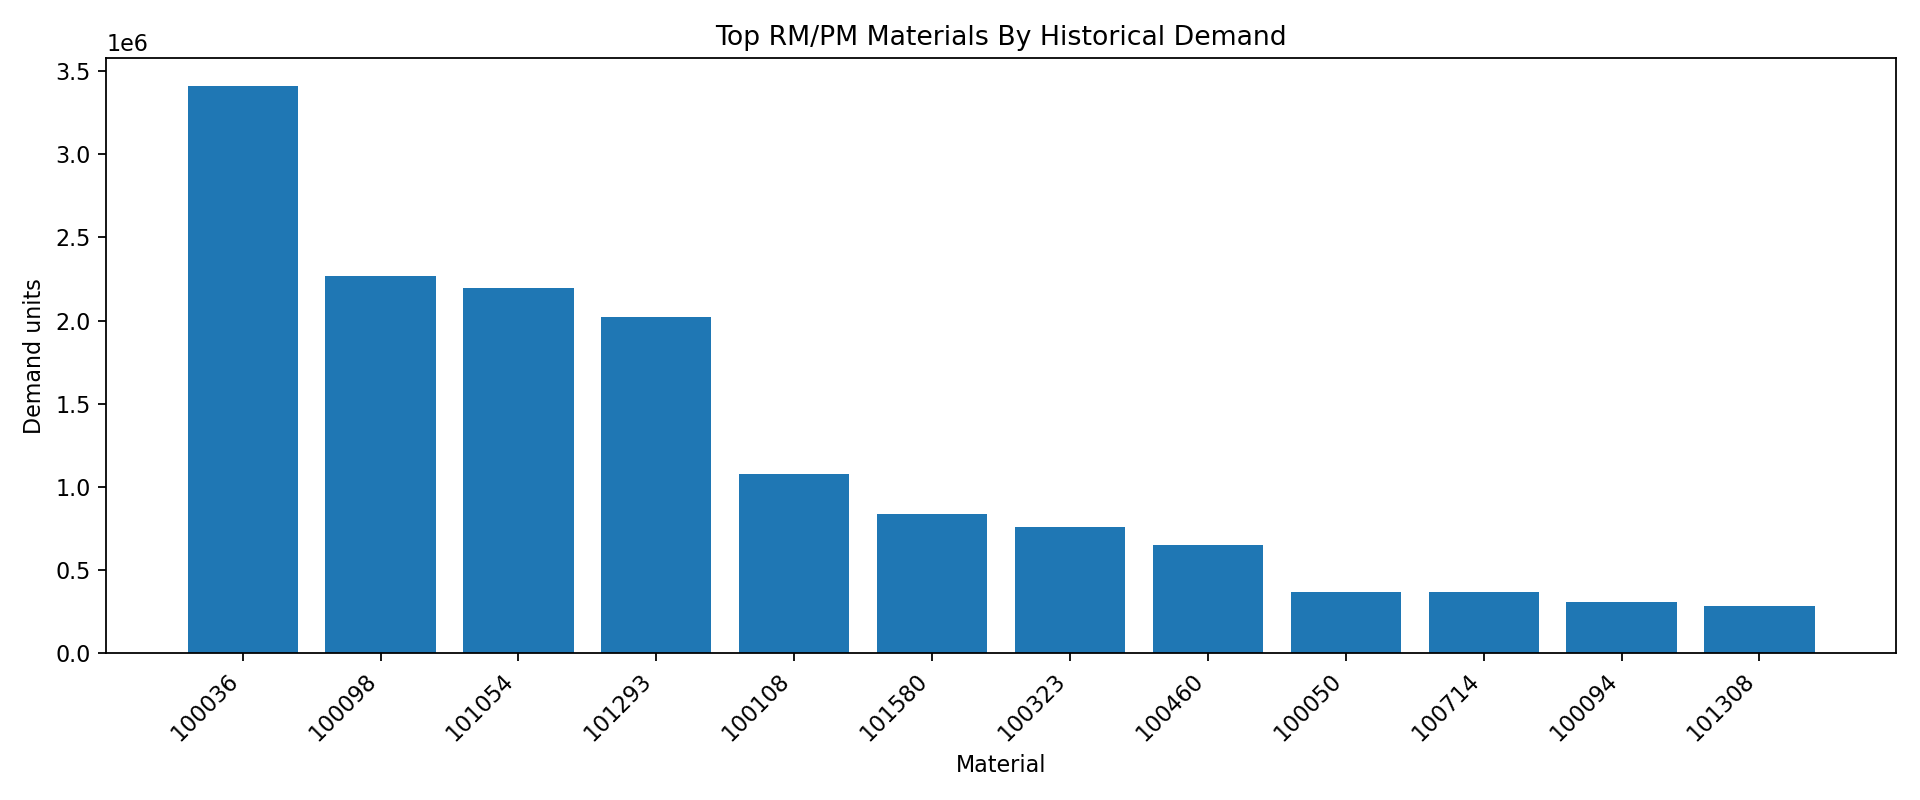

In [5]:
from IPython.display import Image
Image(filename=str(OUT / "plots" / "top_demand_materials.png"))